# Lab 2.3 - Visualizing Relationships Between Categorical Features
### Creating Character Profiles for a Titanic Reboot
In this lab, I use the Titanic passenger datatset to create two historically grounded character profiles: one most likely to survive and one least likely to survive. Each profile is supported by visualizations and data analysis of age, fare, sex, passenger class, travel companions, and port of departure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("titanic_passengers.csv")

## Visualizations for Each Profile Element

### (A) Sex vs Survival

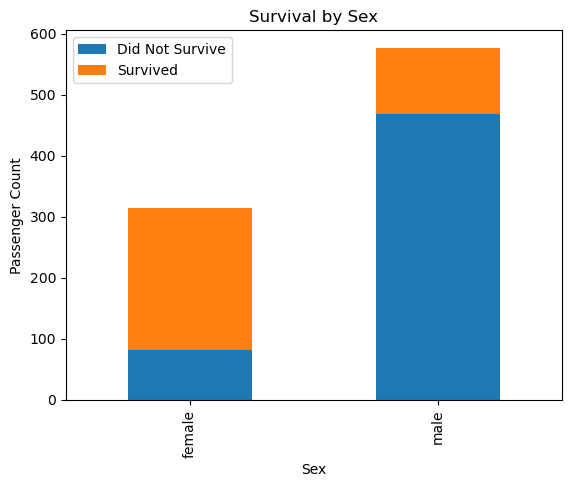

In [2]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
Females survived at a much higher rate than males. The stacked bars show that most women survived, while most men did not.

### (B) Passenger Class vs Survival

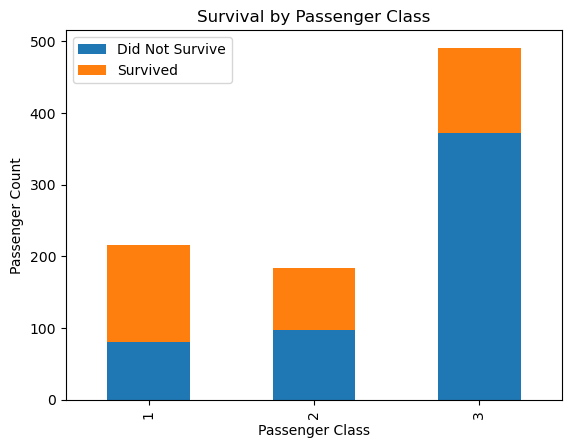

In [3]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
First-class passengers had the highest survival rate, while third-class passengers had the lowest. This suggests that wealth and cabin location influenced access to lifeboats.

### (C) Embarked vs Survival

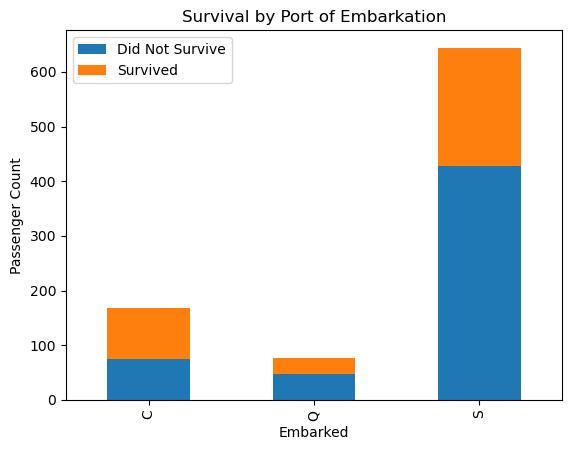

In [4]:
pd.crosstab(df['Embarked'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Port of Embarkation")
plt.xlabel("Embarked")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
Passengers who boarded at Cherbourg (C) had the highest survival rate. Southampton (S) passengers had the lowest.

### (D) Travel Companions (SibSp + Parch)

(D1-SibSp vs Survival)

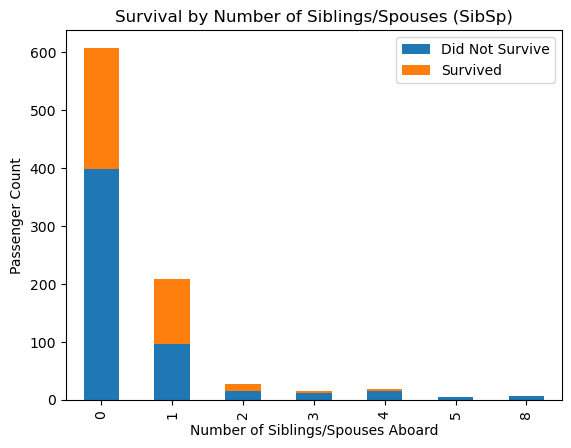

In [5]:
pd.crosstab(df['SibSp'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Number of Siblings/Spouses (SibSp)")
plt.xlabel("Number of Siblings/Spouses Aboard")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
Passengers traveling with 0 or 1 sibling/spouse had higher survival rates than those with larger numbers of companions. Those with 3 or more siblings/spouses had very low survival. This suggests that traveling in a large group made evacuation more difficult.

(D2-Parch vs Survival)

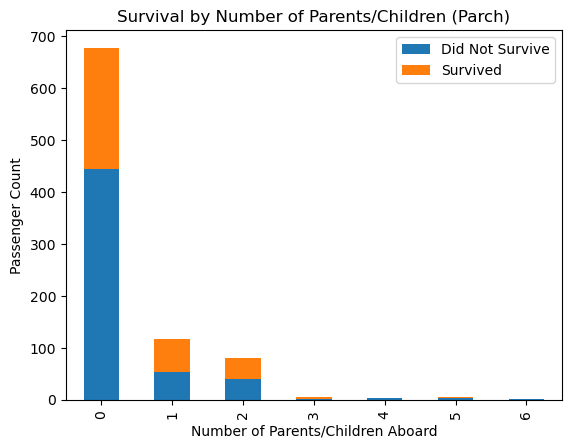

In [6]:
pd.crosstab(df['Parch'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Number of Parents/Children (Parch)")
plt.xlabel("Number of Parents/Children Aboard")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
Passengers with 0 or 1 parent/child had better survival outcomes than those with larger families. Very large family groups (3+) show much lower survival. This pattern reinforces the idea that smaller family units were more likely to reach lifeboats in time.

### (E) Age & Fare

(E1-Create Age Categories) I categorized Age into four groups: Child (0-12), Teen (13-18), Adult (19-40), and Older Adult (41+). These bins reflect meaningful life stages and help compare survival patterns across age groups.

In [7]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 40, 80],
    labels=['Child', 'Teen', 'Adult', 'Older Adult']
)

(E2-Visualize Survival by Age Group)

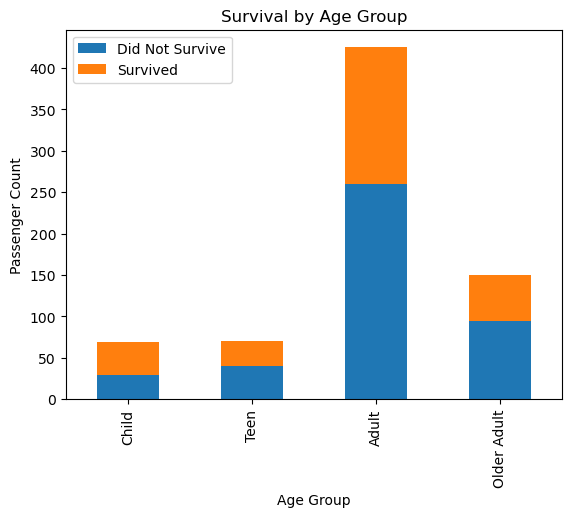

In [8]:
pd.crosstab(df['AgeGroup'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
Survival patterns very by life stage. Children show noticebly higher survival, reflecting the "women and children first" evacuation priority. Adults have mixed outcomes, while older adults show the lowest survival, possibly due to mobility challenges during evacuation.

(E3-Create Fare Categories) I categorized Fare into Low (0-15), Medium (15-40), and High (40+). These ranges roughly correspond to 3rd, 2nd, and 1st class ticket prices, allowing us to comapre survival outcomes across socioeconomic groups.

In [9]:
df['FareGroup'] = pd.cut(
    df['Fare'],
    bins=[0, 15, 40, 600],
    labels=['Low', 'Medium', 'High']
)

(E4-Visualize Survival by Fare Group)

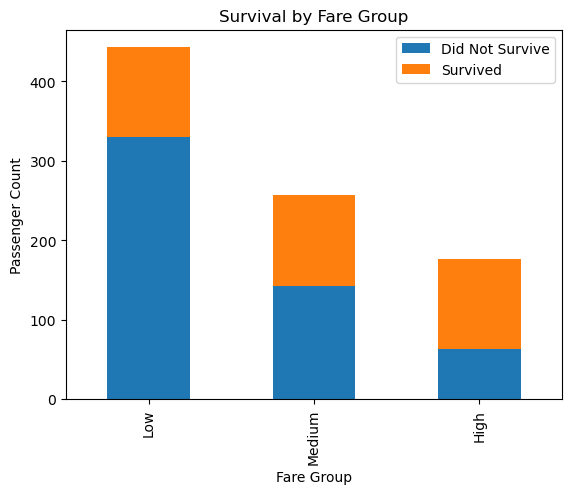

In [10]:
pd.crosstab(df['FareGroup'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Survival by Fare Group")
plt.xlabel("Fare Group")
plt.ylabel("Passenger Count")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

### Interpretation:
Passengers who paid higher fares had better survival outcomes. Higher fare tickets usually placed passengers in cabins closer to the boat deck, reducing evacuation time. Lower fare passengers were located deeper in the ship, which likely limited their access to lifeboats during the sinking.

---

## 'Most Likely to Survive' Character Profile

### - Sex: Female
The Sex vs Survival plot shows that females had a dramatically higher survival rate than males. This reflects the "women and children first" emergency protocol.

### - Passenger Class: 1st Class
The Pclass visualization shows that 1st class passengers had the highest survival rate, with more survivors than non-survivors. This suggests better access to lifeboats and crew assistance.

### - Port of Embarkation: Cherbourg(C)
The Embarked plot shows that passengers who boarded at Cherbourg had the highest proportion of survivors compared to Southampton and Queenstown.

### - Travel Companions (SibSp): 0-1
The SibSp plot shows that passengers traveling alone or with one sibling/spouse had the best survival outcomes while larger groups (3+) had very low survival.

### - Travel Companions (Parch): 1-2
The Parch plot shows that passengers with 1-2 parents/children aboard had the highest survival proportions. Those with 0 had lower survival, and those with 3+ had extremely low survival.

### - Age Group: Child
The AgeGroup plot shows that children had the highest survival proportions. Adults and older adults had much lower survival.

### - Fare Group: High Fare
The FareGroup plot shows that high-fare passengers had the highest survival rate. This likely reflects cabin location closer to the boat deck.

### 'Most Likely to Survive' Character Summary:
Based on the visualiztions, the passenger most likely to survive is a female child traveling in 1st class, who embarked at Cherbourg, paid a high fare, and traveled with a small family group (0-1 siblings/spouses and 1-2 parents/children).

Each of these traits correspond to the highest survival proportions in the dataset, making this character historically consistent with the survival patterns observed on the Titanic.

## 'Least Likely to Survive' Character Profile

### - Sex: Male
The Sex vs Survival plot shows that males had a much lower survival rate than females. The majority of male passengers did not survive.

### - Passenger Class: 3rd Class
The Pclass visualization shows that 3rd class passengers had the lowest survival rate by a wide margin. Most 3rd class passengers did not survive.

### - Port of Embarkation: Queenstown (Q)
The Embarked plot shows that passengers who boarded at Queenstown had the lowest survival proportions. Very few survived compared to Cherbourg or Southampton.

### - Travel Companions (SibSp): Large group (3+ siblings/spouses)
The SibSp plot shows that survival drops sharply once passengers have 3 or more siblings/spouses abroad. These groups had extremely low survival.

### - Travel Companions (Parch): Large group (3+ parents/children)
The Parch plot shows that passengers with 3 or more parents/children aboard had very low survival, with almost no survivors in these categories.

### - Age Group: Older Adult
The AgeGroup plot shows that older adults had low survival compared to children and teens. Adults had many deaths, but older adults had the lowest survival proportions.

### - Fare Group: Low Fare
The FareGroup plot shows that low fare passengers had the lowest survival rate. Most passengers in this group did not survive.

### 'Least Likely to Survive' Character Summary:
Based on the visualizations, the passenger least likely to survive is an older adult male taveling in 3rd class, who embarked at Queenstown, paid a low fare, and traveled with a large family group (3+ siblings/spouses and 3+ parents/children).

Each of these traits corresponds to the lowest survival proportions in the dataset, making this character consistent with the patterns observed in the Titanic data.

---

## Find a real passenger who fits my "Most Likely to Survive" profile

In [13]:
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['AgeGroup'] == 'Child')
]

most_likely[['Name','Age','Sex','Pclass','SibSp','Parch','Embarked','Fare']]

,Name,Age,Sex,Pclass,SibSp,Parch,Embarked,Fare
297,"Allison, Miss. Helen Loraine",2.0,female,1,1,2,S,151.55


### Interesting Fact About Miss. Helen Loraine Allison
One real passenger who fits my "most likely to survive" profile is Miss Helen Loraine Allison, a 2-year old 1st class passenger. According to Encyclopedia Titanica, Loraine Allison was the only child in first and second class to die, and her body was never recovered -- a tragic exeption to the survival patterns that overwhelmingly favored young children in 1st class. I also had to adjust my filtering criteria several times to find a real passenger who matched my profile, which highlights how rare her situation was in the dataset.

## Find a real passenger who fits my "Least Likely to Survive" profile

In [17]:
least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Embarked'] == 'Q') &
    (df['AgeGroup'] == 'Older Adult')
]

least_likely[['Name','Age','Sex','Pclass','SibSp','Parch','Embarked','Fare']]

,Name,Age,Sex,Pclass,SibSp,Parch,Embarked,Fare
116,"Connors, Mr. Patrick",70.5,male,3,0,0,Q,7.75
280,"Duane, Mr. Frank",65.0,male,3,0,0,Q,7.75
525,"Farrell, Mr. James",40.5,male,3,0,0,Q,7.75


### Interesting Fact About Mr. Patrick Connors
One real passenger who fits my "least likely to survive" profile is Mr. Patrick Connors, a 70-year old 3rd class passenger from Queenstown. According to Encyclopedia Titanica, Connors had emigrated from Ireland to New York in 1874, raised a large family of seven children, and was returning to America after spending ten months visiting his sister in County Cork. Despite being described in contemporary newspapers as appearing "in robust health", he perished in the sinking, and his body was later recovered and buried at sea.